In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
file_input = 'dataset_twitter_clean_final.csv'

print(f"{file_input}")
df = pd.read_csv(file_input)

df = df.dropna(subset=['clean_text']).reset_index(drop=True)

print(f"Jumlah baris: {len(df)}")

dataset_twitter_clean_final.csv
Jumlah baris: 8943


In [3]:
url_positif = 'https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv'
url_negatif = 'https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv'

lexicon_positive = pd.read_csv(url_positif, sep='\t')
lexicon_negative = pd.read_csv(url_negatif, sep='\t')

pos_dict = dict(zip(lexicon_positive.iloc[:, 0], lexicon_positive.iloc[:, 1]))
neg_dict = dict(zip(lexicon_negative.iloc[:, 0], lexicon_negative.iloc[:, 1]))

In [ ]:
#kata_negasi = set(['fufufafa', 'mulyono', 'red light distrik', 'gerombolan', ''])

In [4]:
skor_positif_list = []
skor_negatif_list = []
total_skor_list = []
hasil_sentimen = []


In [ ]:
def hitung_skor_transparan(text):
    kata_kata = text.split()
    pos_score = 0
    neg_score = 0

    for i in range(len(kata_kata)):
        kata = kata_kata[i]
        bobot = 0
        is_pos = False
        is_neg = False

        # Cek kata di kamus
        if kata in pos_dict:
            bobot = pos_dict[kata]
            is_pos = True
        elif kata in neg_dict:
            bobot = neg_dict[kata]
            is_neg = True

        if bobot != 0:
            if is_pos:
                pos_score += bobot
            elif is_neg:
                neg_score += bobot

    # Hitung total dan tentukan label
    total = pos_score + neg_score
    if total > 0:
        label = 'Positif'
    elif total < 0:
        label = 'Negatif'
    else:
        label = 'Netral'

    # Mengembalikan 4 nilai sekaligus sebagai Series Pandas
    return pd.Series([pos_score, neg_score, total, label])

In [6]:
df[['skor_positif', 'skor_negatif', 'total_skor', 'label']] = df['clean_text'].apply(hitung_skor_transparan)

In [7]:
file_output = 'dataset_twitter_berlabel_inset.csv'
df.to_csv(file_output, index=False)

print(f"Proses selesai! File berhasil disimpan di: {file_output}")

Proses selesai! File berhasil disimpan di: dataset_twitter_berlabel_inset.csv


In [ ]:
kolom_tampil = ['clean_text', 'skor_positif', 'skor_negatif', 'total_skor', 'label']

print("\nHASIL PELABELAN INSET")
pd.set_option('display.max_colwidth', None)
display(df[kolom_tampil].head(12))

print("\nDistribusi Kelas Sentimen:")
distribusi_label = df['label'].value_counts().reset_index()
distribusi_label.columns = ['Label', 'Jumlah']
display(distribusi_label)


HASIL PELABELAN INSET + SENTISTRENGTH


,clean_text,skor_positif,skor_negatif,total_skor,label
0,yang pasti bukan yang kere kayak lu,3,-16,-13,Negatif
1,para pendukung ikn adalah manusia korup tak bertanggung jawab,12,-5,7,Positif
2,gue berharap jangan sampai kejadian takut sih mul entar dituntut rakyat,10,-3,7,Positif
3,faktanya apa ada anggota dpr yang usul jadi ibu kota provinsi you cari tahu jangan cuma saras soros,11,-21,-10,Negatif
4,tempe medianya soros kemarin bilang hutan mangkrak kwkwkw sisanya berita cuma dari katanya mirip koran gosip wkw,4,-16,-12,Negatif
5,mau jadi apapun gue sih setuju dengan syarat proses hukum dulu lah aktor pembangunan ikn nya dia sudah menghambur hamburkan duit rakyat padahal katanya di kantongnya ada rp t setuju enggak,25,-4,21,Positif
6,enggak bakal kemana indonesia,0,0,0,Netral
7,memang harus mati semua dulu elit negeri ini mereka tidak ada keinginan untuk sedikit membangun negeri ini saling menutupi dan bekerjasama agar kelak ketika gilirannya berkuasa mereka bisa saling membantu assuuuu kabeh,20,-22,-2,Negatif
8,ternyata mas bowo juga masuk list gerombolan nya mas joko,0,-7,-7,Negatif
9,mengapai wakil presiden dikasih istana,5,0,5,Positif



Distribusi Kelas Sentimen:


,Label,Jumlah
0,Negatif,4194
1,Positif,4066
2,Netral,683


In [9]:
sns.set(style="whitegrid")

C:\Users\Kevin\AppData\Local\Temp\ipykernel_15340\933917598.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, order=urutan, palette=warna_batang)


Text(0, 0.5, 'Jumlah Tweet')

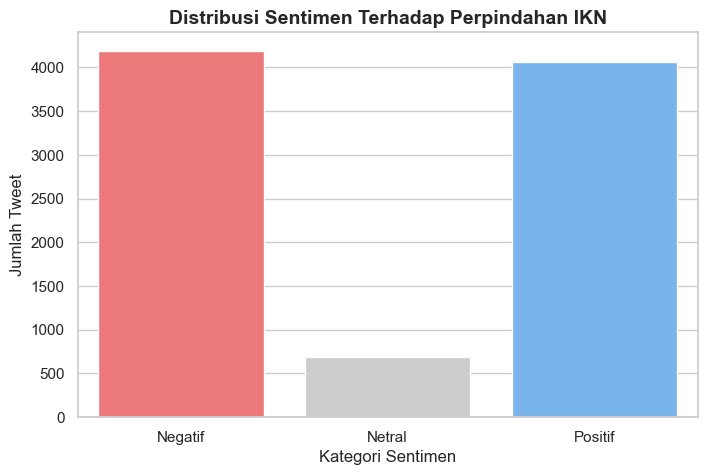

In [10]:
plt.figure(figsize=(8, 5))
# Membuat urutan grafik menjadi teratur: Negatif, Netral, Positif
urutan = ['Negatif', 'Netral', 'Positif']
warna_batang = ['#ff6666', '#cccccc', '#66b3ff'] # Merah, Abu-abu, Biru

ax = sns.countplot(x='label', data=df, order=urutan, palette=warna_batang)
plt.title('Distribusi Sentimen Terhadap Perpindahan IKN', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Sentimen', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

In [11]:
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

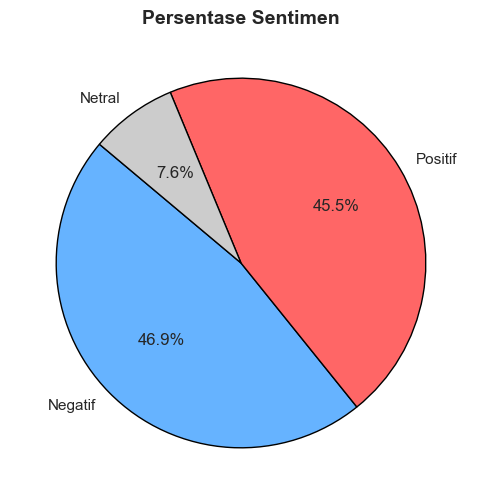

In [12]:
plt.figure(figsize=(6, 6))
jumlah_label = df['label'].value_counts()
warna_pie = ['#66b3ff', '#ff6666', '#cccccc'] # Menyesuaikan dengan urutan value_counts yang otomatis dari terbesar

plt.pie(jumlah_label, labels=jumlah_label.index, autopct='%1.1f%%',
        startangle=140, colors=warna_pie, wedgeprops={'edgecolor': 'black'})
plt.title('Persentase Sentimen', fontsize=14, fontweight='bold')
plt.show()

In [13]:
def buat_wordcloud(teks_gabungan, judul, warna_latar):
    if not teks_gabungan.strip():
        print(f"Tidak ada data untuk {judul}")
        return

    wordcloud = WordCloud(width=800, height=400,
                          background_color=warna_latar,
                          colormap='viridis',
                          max_words=100).generate(teks_gabungan)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(judul, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

In [14]:
teks_positif = ' '.join(df[df['label'] == 'Positif']['clean_text'])
teks_negatif = ' '.join(df[df['label'] == 'Negatif']['clean_text'])


MEMUAT AWAN KATA (WORD CLOUD)...



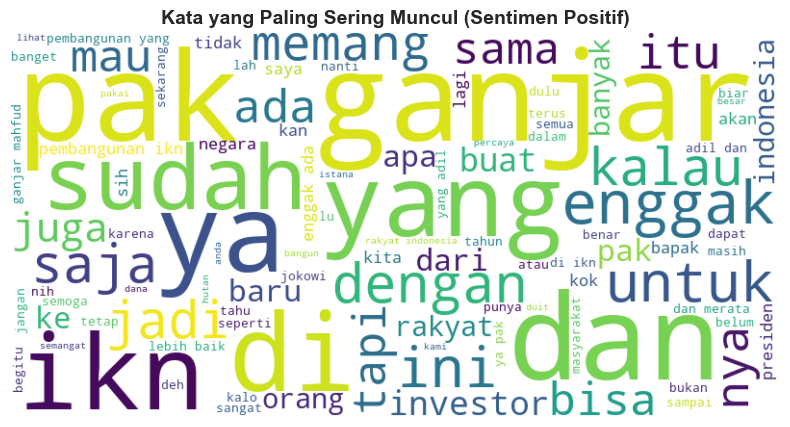

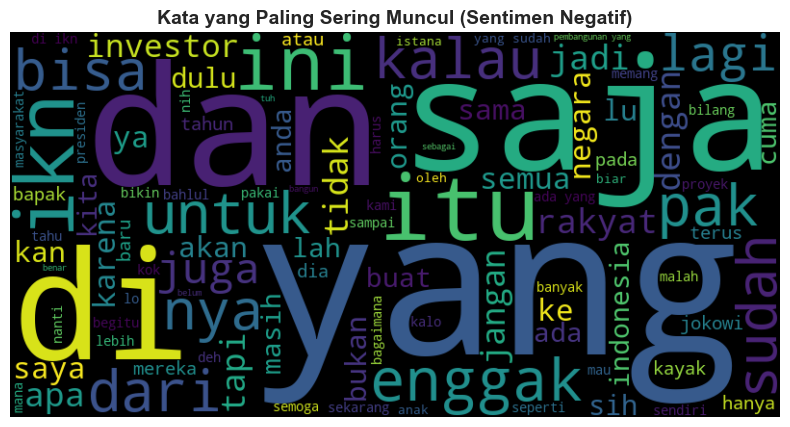

In [15]:
print("\nMEMUAT AWAN KATA (WORD CLOUD)...\n")
buat_wordcloud(teks_positif, 'Kata yang Paling Sering Muncul (Sentimen Positif)', 'white')
buat_wordcloud(teks_negatif, 'Kata yang Paling Sering Muncul (Sentimen Negatif)', 'black')